In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('C:\\Users\\Sarah\\Downloads\\France.csv')

In [3]:
df

,ID,Host ID,Host Name,Host Since,Host Response Rate,Host Listings Count,Host Total Listings Count,City,State,Zipcode,...,Security Deposit,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Number of Reviews,Review Scores Rating,Cancellation Policy,Reviews per Month
0,6165738,31986651,Bernard,42120.0,100.0,1.0,1.0,Thoiry,Rhône-Alpes,1710,...,NaN,NaN,1,0,1,1125,0,NaN,flexible,NaN
1,13908935,82489826,Enice,42559.0,100.0,1.0,1.0,Gaillard,Auvergne Rhône-Alpes,74240,...,560.0,28.0,1,6,2,30,1,80.0,moderate,1.00
2,7713011,32492446,Vincent,42127.0,100.0,7.0,7.0,Paris,Île-de-France,75018,...,100.0,30.0,1,5,4,365,37,85.0,strict,1.84
3,3335054,2726446,Pascale,41084.0,NaN,1.0,1.0,Paris,Île-de-France,75018,...,150.0,15.0,1,0,3,1125,1,100.0,moderate,0.03
4,10066518,30432969,Lea,42095.0,95.0,2.0,2.0,Paris,Île-de-France,75018,...,NaN,15.0,1,0,2,1125,13,97.0,moderate,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56557,2610162,13368008,Réda,41719.0,60.0,1.0,1.0,Paris,Île-de-France,75007,...,250.0,10.0,1,0,2,91,14,85.0,moderate,1.06
56558,13760682,8684576,H. M.,41524.0,83.0,2.0,2.0,Paris,Île-de-France,75007,...,NaN,100.0,4,50,2,15,4,100.0,strict,0.56
56559,9173969,47740911,Host,42306.0,NaN,1.0,1.0,Paris,Île-de-France,75007,...,NaN,NaN,1,0,1,1125,0,NaN,flexible,NaN
56560,13754942,35042224,Arnaud,42160.0,NaN,1.0,1.0,Paris,Île-de-France,75007,...,500.0,36.0,1,0,4,500,3,100.0,strict,0.34


In [4]:
# Creating a back up copy of the original data

df_copy = df.copy()

In [5]:
# Dataset column details
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56562 entries, 0 to 56561
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         56562 non-null  int64  
 1   Host ID                    56562 non-null  int64  
 2   Host Name                  56551 non-null  object 
 3   Host Since                 56551 non-null  float64
 4   Host Response Rate         37832 non-null  float64
 5   Host Listings Count        56551 non-null  float64
 6   Host Total Listings Count  56551 non-null  float64
 7   City                       56532 non-null  object 
 8   State                      56489 non-null  object 
 9   Zipcode                    55821 non-null  object 
 10  Country                    56562 non-null  object 
 11  Property Type              56562 non-null  object 
 12  Room Type                  56562 non-null  object 
 13  Accommodates               56562 non-null  int

In [6]:
# Checking for null values in each column
print(df.isnull().sum())

ID                               0
Host ID                          0
Host Name                       11
Host Since                      11
Host Response Rate           18730
Host Listings Count             11
Host Total Listings Count       11
City                            30
State                           73
Zipcode                        741
Country                          0
Property Type                    0
Room Type                        0
Accommodates                     0
Bathrooms                      184
Bedrooms                       134
Beds                            75
Bed Type                         0
Amenities                      428
Price                           57
Weekly Price                 40234
Monthly Price                44214
Security Deposit             25435
Cleaning Fee                 20762
Guests Included                  0
Extra People                     0
Minimum Nights                   0
Maximum Nights                   0
Number of Reviews   

In [7]:
# Zipcode, City and State

# Dictionary for certain zipcodes
zipcode_dict = {
    "1210": np.nan, "1280": np.nan, "1710": np.nan, "7015": np.nan,
    "98712": np.nan, "700014": np.nan, "750016": "75016", "750018": "75018",
    "75 018": "75018", "75003\n75003": "75003", "75011 PARIS": "75011",
    "75011\n75011": "75011", "75014\n75014": "75014", "75018e": "75018",
    "adf": np.nan, "N": np.nan, "Montmartre": "75018", "750109": "75019",
    "Paris": "75", "Paris 75004": "75004"}

df["Zipcode"] = df["Zipcode"].replace(zipcode_dict)

df['Zipcode'] = df['Zipcode'].astype(str).str.strip()

# Keep only zipcodes that are exactly 5 digits
valid_zip = df['Zipcode'].str.len() == 5
numeric_zip = df['Zipcode'].str.isdigit()

valid_french_zip = valid_zip & numeric_zip

# Set invalid zipcodes to NaN
df.loc[valid_french_zip == False, 'Zipcode'] = np.nan

# City

zip_to_city = {
    # Haute-Savoie (74)
    "74240": "Gaillard", "74160": "Saint-Julien-en-Genevois","74100": "Annemasse",
    "74140": "Douvaine", "74400": "Chamonix-Mont-Blanc", "74580": "Viry",

    # Paris (75)
    "75000": "Paris", "75001": "Paris", "75002": "Paris", "75003": "Paris", "75004": "Paris", "75005": "Paris",
    "75006": "Paris", "75007": "Paris", "75008": "Paris", "75009": "Paris", "75010": "Paris",
    "75011": "Paris", "75012": "Paris", "75013": "Paris", "75014": "Paris", "75015": "Paris", "75016": "Paris",
    "75017": "Paris", "75018": "Paris", "75019": "Paris", "75020": "Paris", "75106": "Paris", "75116": "Paris", "75": "Paris",

    # Yvelines (78)
    "78005": "Versailles", "78008": "Versailles",

    # Hauts-de-Seine (92)
    "92100": "Boulogne-Billancourt", "92110": "Clichy", "92120": "Montrouge", "92130": "Issy-les-Moulineaux",
    "92150": "Suresnes", "92170": "Vanves", "92200": "Neuilly-sur-Seine", "92210": "Saint-Cloud", "92240": "Malakoff", "92300": "Levallois-Perret",

    # Seine-Saint-Denis (93)
    "93100": "Montreuil", "93170": "Bagnolet", "93200": "Saint-Denis", "93210": "La Plaine-Saint-Denis", "93260": "Les Lilas",
    "93300": "Aubervilliers", "93310": "Le Pré-Saint-Gervais", "93400": "Saint-Ouen-sur-Seine", "93500": "Pantin",

    # Val-de-Marne (94)
    "94120": "Fontenay-sous-Bois", "94130": "Nogent-sur-Marne", "94160": "Saint-Mandé", "94200": "Ivry-sur-Seine",
    "94220": "Charenton-le-Pont", "94250": "Gentilly", "94270": "Le Kremlin-Bicêtre",
    "94300": "Vincennes", "94340": "Joinville-le-Pont", "94410": "Saint-Maurice",

    # Val-d’Oise (95)
    "95170": "Deuil-la-Barre",
}

# Use map on city column using zipcode
df["City"] = df["Zipcode"].map(zip_to_city)

city_dict = {
    "Le Kremlin-BicÃªtre": "Le Kremlin-Bicêtre",
    "Le PrÃ©-Saint-Gervais": "Le Pré-Saint-Gervais",
    "Saint-MandÃ©": "Saint-Mandé"}

df["City"] = df["City"].replace(city_dict)

In [8]:
# State

city_to_state = {
    # Île-de-France (Paris region)
    "Paris": "Île-de-France",
    "Clichy": "Île-de-France",
    "Pantin": "Île-de-France",
    "Le Pré-Saint-Gervais": "Île-de-France",
    "Aubervilliers": "Île-de-France",
    "Deuil-la-Barre": "Île-de-France",
    "Issy-les-Moulineaux": "Île-de-France",
    "Charenton-le-Pont": "Île-de-France",
    "Ivry-sur-Seine": "Île-de-France",
    "Le Kremlin-Bicêtre": "Île-de-France",
    "Saint-Ouen-sur-Seine": "Île-de-France",
    "Neuilly-sur-Seine": "Île-de-France",
    "Boulogne-Billancourt": "Île-de-France",
    "Bagnolet": "Île-de-France",
    "Saint-Mandé": "Île-de-France",
    "Gentilly": "Île-de-France",
    "Montrouge": "Île-de-France",
    "Saint-Maurice": "Île-de-France",
    "Vanves": "Île-de-France",
    "Joinville-le-Pont": "Île-de-France",
    "Fontenay-sous-Bois": "Île-de-France",
    "Vincennes": "Île-de-France",
    "Saint-Denis": "Île-de-France",
    "Les Lilas": "Île-de-France",
    "Suresnes": "Île-de-France",
    "Malakoff": "Île-de-France",
    "Montreuil": "Île-de-France",
    "La Plaine-Saint-Denis": "Île-de-France",
    "Nogent-sur-Marne": "Île-de-France",
    "Versailles": "Île-de-France",
    "Levallois-Perret": "Île-de-France",
    "Saint-Cloud": "Île-de-France",

    # Auvergne-Rhône-Alpes (Haute-Savoie)
    "Gaillard": "Auvergne-Rhône-Alpes",
    "Saint-Julien-en-Genevois": "Auvergne-Rhône-Alpes",
    "Chamonix-Mont-Blanc": "Auvergne-Rhône-Alpes",
    "Annemasse": "Auvergne-Rhône-Alpes",
    "Douvaine": "Auvergne-Rhône-Alpes",
    "Viry": "Auvergne-Rhône-Alpes"
}

df["State"] = df["City"].map(city_to_state)

In [9]:
# Amenities
df['Amenities'] = df['Amenities'].fillna('No amenities listed')

def clean_amenities(df):

    df['Amenities Count'] = (
        df['Amenities']
        .str.lower()
        .apply(lambda x: 0 if x == 'no amenities listed' else len(x.split(',')))
    )

    return df

df = clean_amenities(df)

In [10]:
# Host Since

df["Host Since"] = pd.to_datetime(df["Host Since"], origin="1899-12-30", unit="D", errors="coerce")

In [11]:
# Columns and Rows to be dropped

# Host related columns

host_cols = [
    "Host Name",
    "Host Since",
    "Host Response Rate",
    "Host Listings Count",
    "Host Total Listings Count"
]

# Drop rows where all host related information is missing
df = df.dropna(subset=host_cols, how="all")

# Drop empty City rows
df = df.dropna(subset=['City'])

# Drop Host Total Listings count as it is identical to another column
if df['Host Listings Count'].equals(df['Host Total Listings Count']):
    df = df.drop(columns=['Host Total Listings Count'])

# Drop the Weekly Price and Monthly Price
df = df.drop(columns=['Weekly Price', 'Monthly Price'])

In [12]:
# Check datatypes of columns

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 55795 entries, 1 to 56561
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    55795 non-null  int64         
 1   Host ID               55795 non-null  int64         
 2   Host Name             55795 non-null  object        
 3   Host Since            55795 non-null  datetime64[ns]
 4   Host Response Rate    37340 non-null  float64       
 5   Host Listings Count   55795 non-null  float64       
 6   City                  55795 non-null  object        
 7   State                 55795 non-null  object        
 8   Zipcode               55795 non-null  object        
 9   Country               55795 non-null  object        
 10  Property Type         55795 non-null  object        
 11  Room Type             55795 non-null  object        
 12  Accommodates          55795 non-null  int64         
 13  Bathrooms            

In [13]:
# Change datatypes

int_cols = [
    'Host Response Rate',
    'Host Listings Count',
    'Bedrooms',
    'Beds',
    'Price',
    'Security Deposit',
    'Cleaning Fee',
    'Guests Included',
    'Extra People',
    'Minimum Nights',
    'Maximum Nights',
    'Number of Reviews',
    'Amenities Count'
]

for col in int_cols:
    df[col] = df[col].astype('Int64')

In [14]:
# Fill numerical columns
# Impute with median
median_cols = [
    'Host Response Rate',
    'Bathrooms',
    'Bedrooms',
    'Beds',
    'Review Scores Rating',
    'Price'
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute with 0
zero_cols = [
    'Security Deposit',
    'Cleaning Fee',
    'Reviews per Month'
]

for col in zero_cols:
    df[col] = df[col].fillna(0)

In [15]:
# After filling missing values

print(df.isnull().sum())

ID                      0
Host ID                 0
Host Name               0
Host Since              0
Host Response Rate      0
Host Listings Count     0
City                    0
State                   0
Zipcode                 0
Country                 0
Property Type           0
Room Type               0
Accommodates            0
Bathrooms               0
Bedrooms                0
Beds                    0
Bed Type                0
Amenities               0
Price                   0
Security Deposit        0
Cleaning Fee            0
Guests Included         0
Extra People            0
Minimum Nights          0
Maximum Nights          0
Number of Reviews       0
Review Scores Rating    0
Cancellation Policy     0
Reviews per Month       0
Amenities Count         0
dtype: int64


In [16]:
# Outliers treatment

outlier_cols = [
    'Maximum Nights', 'Minimum Nights', 'Cleaning Fee',
    'Extra People', 'Security Deposit',
    'Number of Reviews', 'Reviews per Month']

def clip_outliers(df, col):
    df[col] = df[col].astype(float)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)
    return df

for col in outlier_cols:
    if col in df.columns:
        df = clip_outliers(df, col)

In [17]:
# Change the datatypes back to int

for col in int_cols:
    df[col] = df[col].round().astype("Int64")

In [18]:
# Take a copy of the cleaned dataframe

df_cleaned = df.copy()

In [19]:
# Save the cleaned dataframe

df.to_csv('Cleaned_France_data.csv', index=False)

In [20]:
pip install sqlalchemy pymysql pandas

Note: you may need to restart the kernel to use updated packages.


In [21]:
df_sql = df_cleaned.copy()

df_sql = df_sql.drop(['Amenities'], axis=1)

from sqlalchemy import create_engine

# MySQL connection
engine = create_engine(f"mysql+pymysql://{uname}:{pwd}@{hostname}:{port}/{dbname}")

# Import DataFrame into SQL
df_sql.to_sql('france_data', con=engine, if_exists='replace', index=False)

55795

# Exploratory Data Analysis

## 1. Listing and Host Performance Analysis:

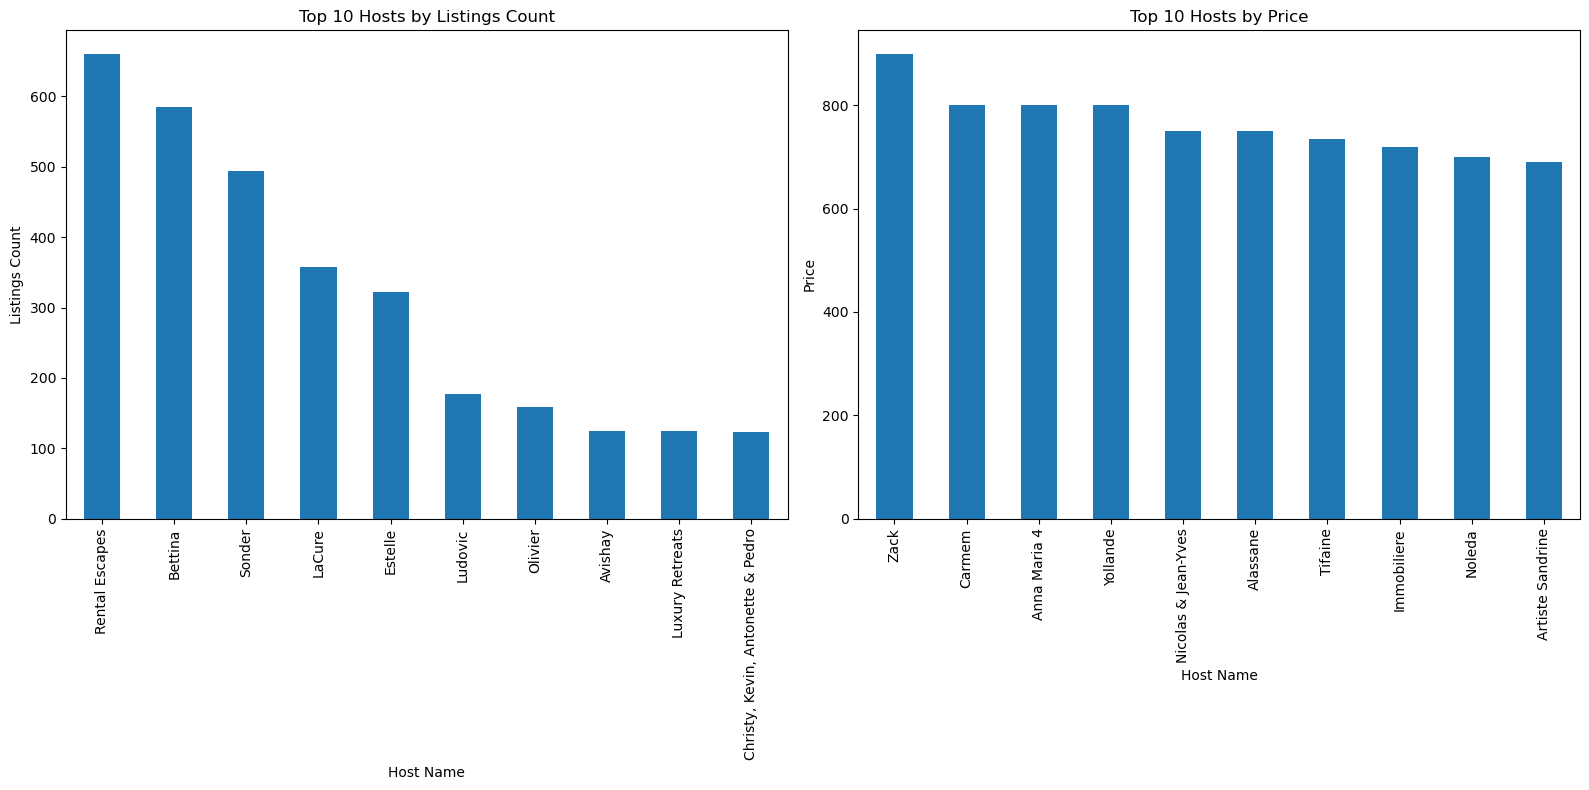

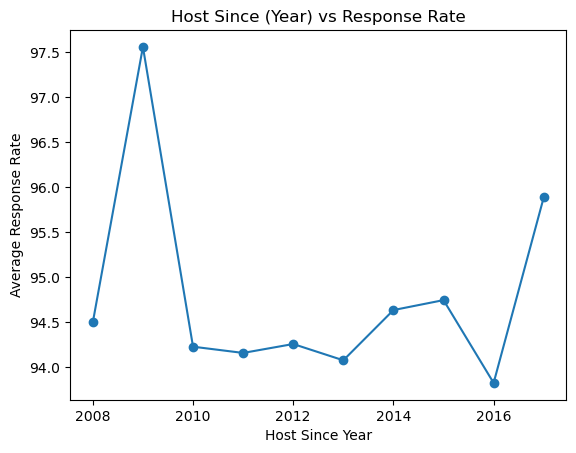

In [22]:
plt.figure(figsize=(16, 8))

# Top 10 Hosts by Listings Count
plt.subplot(1, 2, 1)
df.groupby('Host Name')['Host Listings Count'].max().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Hosts by Listings Count")
plt.xlabel("Host Name")
plt.ylabel("Listings Count")

# Top 10 Hosts by Price
plt.subplot(1, 2, 2)
df.groupby('Host Name')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Hosts by Price")
plt.xlabel("Host Name")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Response Rate by Year of Joining
df['Host Year'] = df['Host Since'].dt.year

df.groupby('Host Year')['Host Response Rate'].mean().plot(kind='line', marker='o')
plt.title("Host Since (Year) vs Response Rate")
plt.xlabel("Host Since Year")
plt.ylabel("Average Response Rate")
plt.show()

**Interpretation:**

1. A small group of hosts manages a disproportionately large number of listings, while most hosts operate at a much smaller scale, indicating the presence of both professional operators and individual hosts in the market.

2. High-priced listings are distributed across different hosts, and not limited to those with the largest portfolios, suggesting that pricing is driven more by property features and location than host size.

3. Response rates remain consistently high across all host experience levels, indicating that responsiveness is a standard expectation on the platform rather than a factor influenced by host tenure.

## 2. Customer Experience & Satisfaction

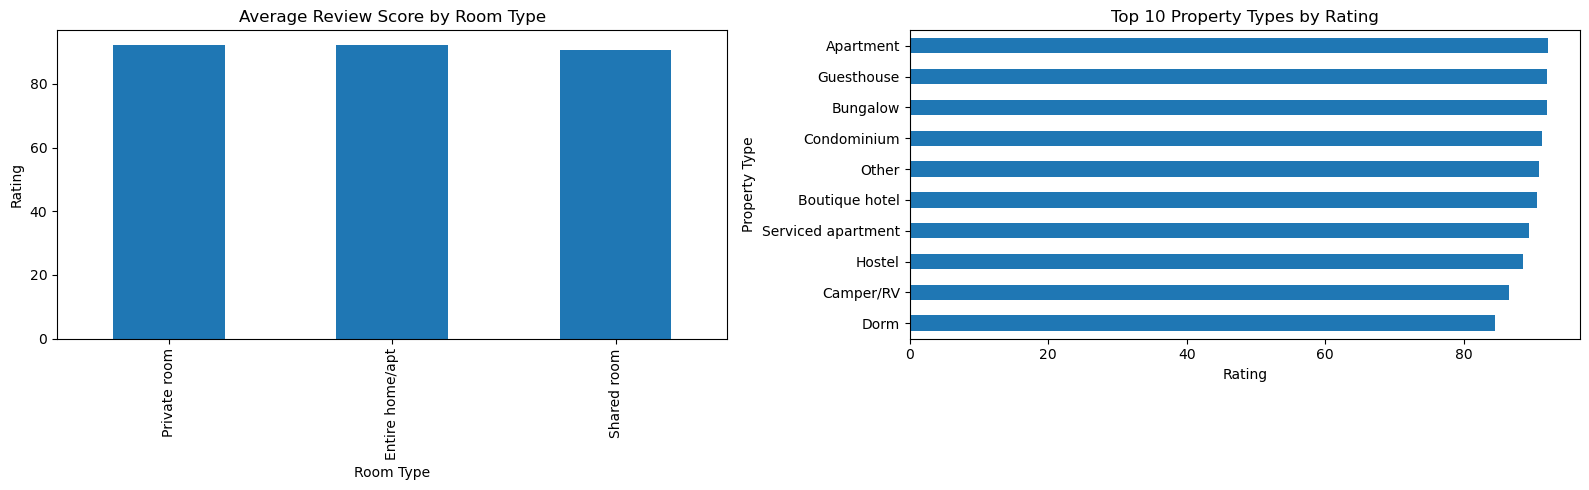

The correlation coefficient of Reviews per Month and Number of Reviews: 0.74


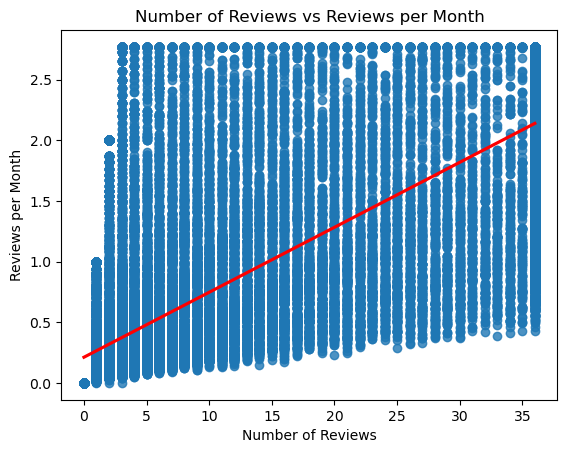

In [23]:
plt.figure(figsize=(16, 5))

# # Average Review Score by Room Type
plt.subplot(1, 2, 1)
df.groupby('Room Type')['Review Scores Rating'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Review Score by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Rating")

# Top 10 Property Types by Review Scores Rating
plt.subplot(1, 2, 2)
df.groupby('Property Type')['Review Scores Rating'].mean().sort_values().head(10).plot(kind='barh')
plt.title("Top 10 Property Types by Rating")
plt.xlabel("Rating")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

# Correlation between Number of Reviews and Reviews per Month
corr_reviewsmonth_number = df['Reviews per Month'].corr(df['Number of Reviews'])
print(f"The correlation coefficient of Reviews per Month and Number of Reviews: {corr_reviewsmonth_number:.2f}")

sns.regplot(x='Number of Reviews', y='Reviews per Month', data=df, line_kws={'color': 'red'})
plt.title('Number of Reviews vs Reviews per Month')
plt.show()

**Interpretation:**

1. Review scores are consistently high across all room types with very minimal variation, indicating that customer satisfaction is stable and not significantly influenced by the type of accommodation.

2. Different property types achieve similarly high ratings, suggesting that customer satisfaction is maintained across diverse property categories, with only slight differences between them.

3. There is a strong positive relationship between total reviews and reviews per month (correlation ≈ 0.74), indicating that listings with more overall reviews tend to have higher ongoing engagement and demand.

## 3. Property Attributes & Amenities Insights

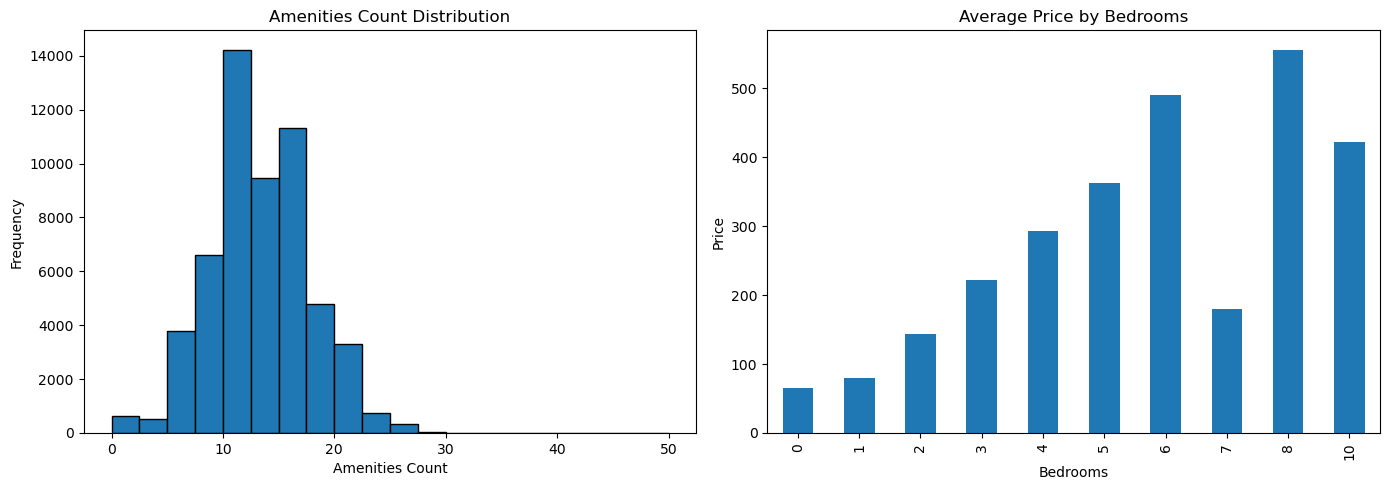

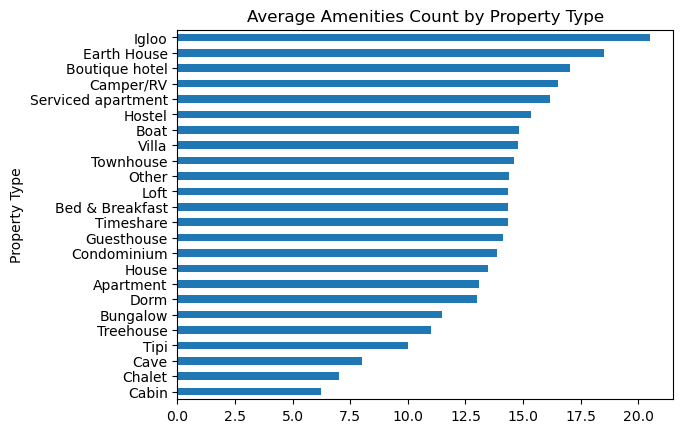

In [24]:
plt.figure(figsize=(14, 5))

# Amenities Count Distribution
plt.subplot(1, 2, 1)
df['Amenities Count'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Amenities Count Distribution")
plt.xlabel("Amenities Count")

# Average Price by Bedrooms
plt.subplot(1, 2, 2)
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')
plt.title("Average Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

# Average Amenities Count by Property Type
df.groupby('Property Type')['Amenities Count'].mean().sort_values().plot(
    kind='barh', title='Average Amenities Count by Property Type')
plt.show()

**Interpretation:**

1. Most listings have a moderate number of amenities (around 10–15), indicating a standard level of feature offerings, while very high or very low amenity counts are relatively rare.

2. Prices generally increase with the number of bedrooms, showing that larger properties command higher prices, although slight variations suggest other factors also influence pricing.

3. Amenities vary across property types, with unique and premium properties offering more amenities, while standard property types maintain moderate and consistent feature levels.

## 4. Demand & Booking Behavior Trends

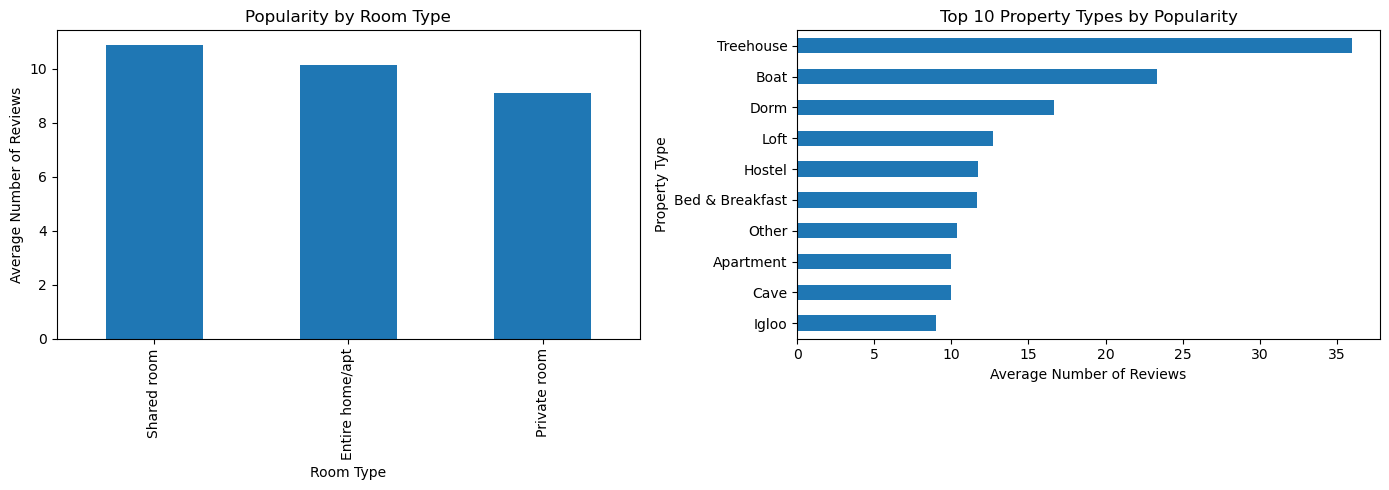

In [25]:
plt.figure(figsize=(14, 5))

# Popularity by Room Type
plt.subplot(1, 2, 1)
df.groupby('Room Type')['Number of Reviews'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Popularity by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Number of Reviews")

# Top 10 Property Type by Popularity
plt.subplot(1, 2, 2)
top10_property_demand = df.groupby('Property Type')['Number of Reviews'].mean().sort_values(ascending=False).head(10)

top10_property_demand.sort_values().plot(kind='barh')
plt.title("Top 10 Property Types by Popularity")
plt.xlabel("Average Number of Reviews")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

**Interpretation:**

1. Most listings have a moderate number of amenities (around 10–15), indicating a standard level of feature offerings, while very high or very low amenity counts are relatively rare.

2. Prices generally increase with the number of bedrooms, showing that larger properties command higher prices, although slight variations suggest other factors also influence pricing.

3. Amenities vary across property types, with unique and premium properties offering more amenities, while standard property types maintain moderate and consistent feature levels.

## 5. Cancellation & Security Policies

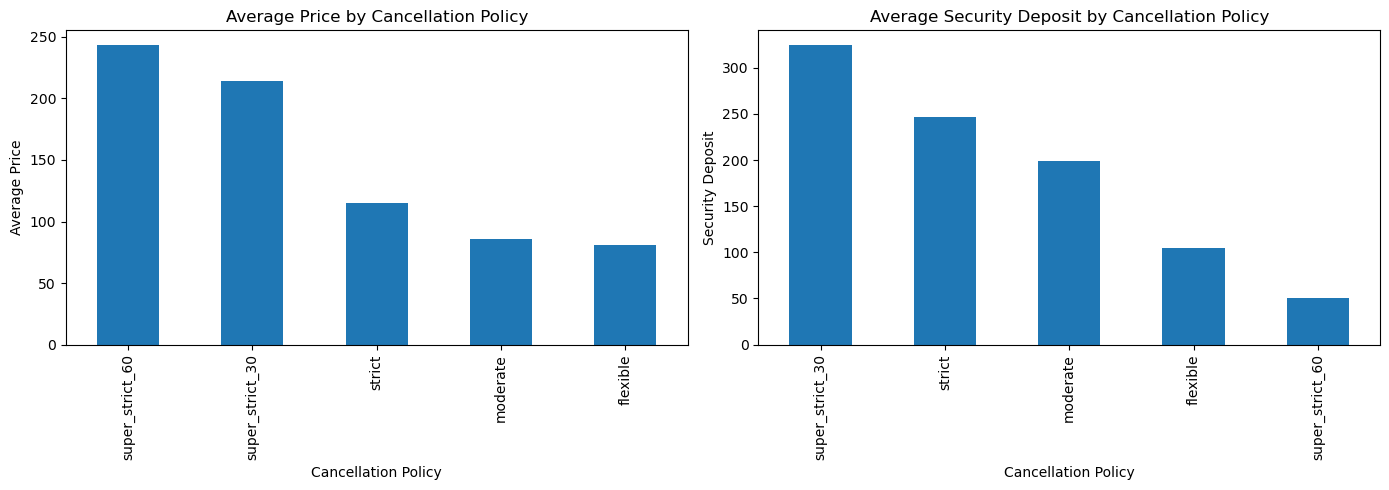

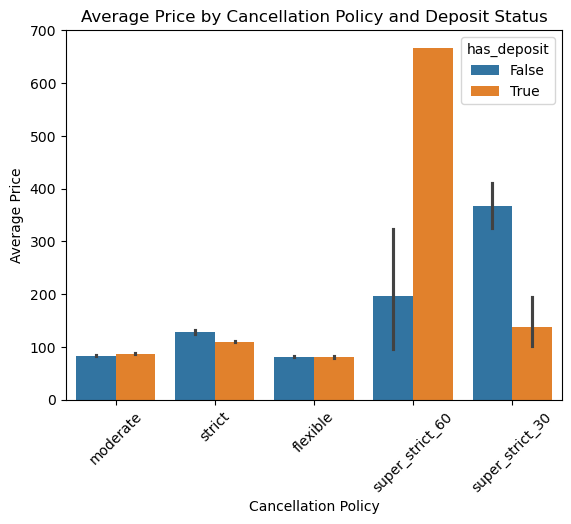

In [26]:
plt.figure(figsize=(14, 5))

# Average Price by Cancellation Policy
plt.subplot(1, 2, 1)
df.groupby('Cancellation Policy')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Price by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")

# Average Security Deposit by Cancellation Policy
plt.subplot(1, 2, 2)
df.groupby('Cancellation Policy')['Security Deposit'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Security Deposit by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Security Deposit")

plt.tight_layout()
plt.show()

# Average Price by Cancellation Policy and Deposit Status
df['has_deposit'] = df['Security Deposit'] > 0

sns.barplot(x='Cancellation Policy', y='Price', hue='has_deposit', data=df)
plt.title("Average Price by Cancellation Policy and Deposit Status")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")
plt.xticks(rotation = 45)
plt.show()

**Interpretation:**

1. Listings with stricter cancellation policies command significantly higher prices, while more flexible policies are associated with lower pricing, indicating a trade-off between pricing power and customer flexibility.

2. Security deposits increase with stricter cancellation policies, suggesting that higher-risk or premium listings enforce stronger financial safeguards.

3. Listings with security deposits generally have higher prices, especially under stricter policies, but super-strict categories show extreme price variation. This suggests deposit requirements are more common in higher-risk or premium-priced listings.

## 6. Geospatial and Location Based Insights

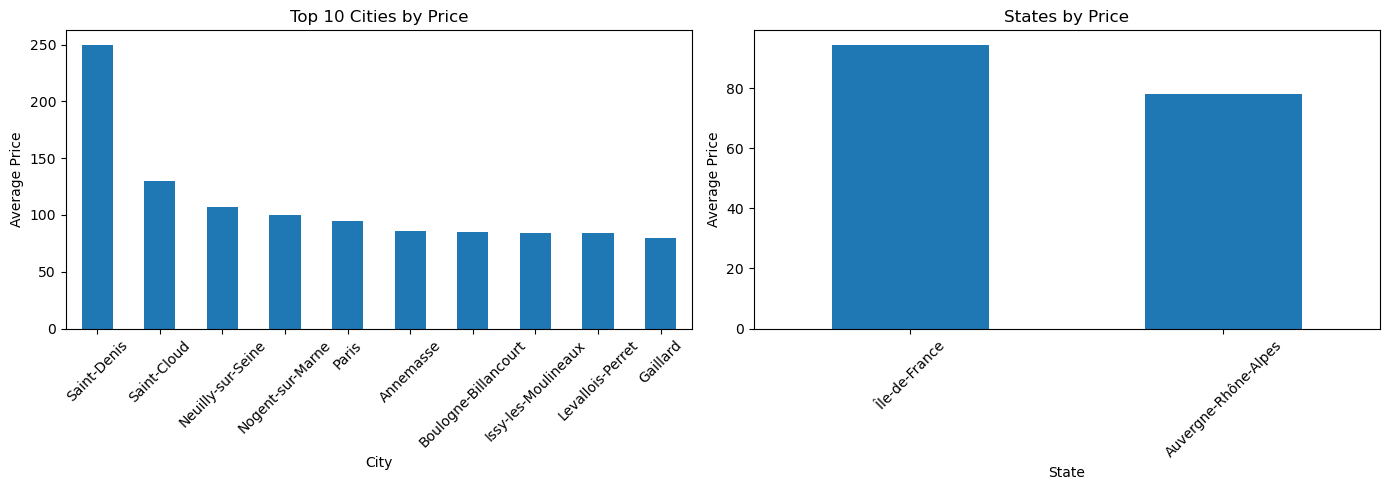

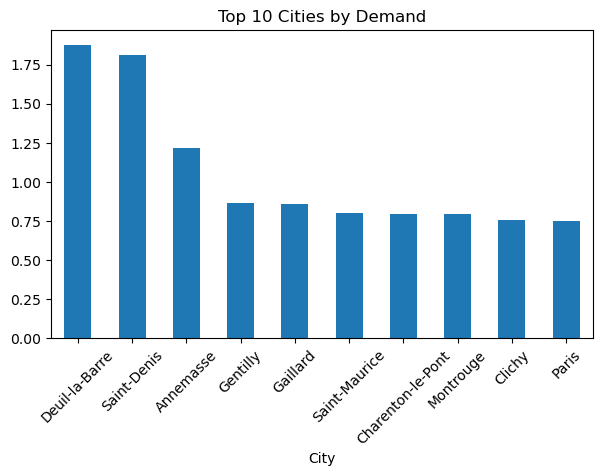

In [27]:
plt.figure(figsize=(14, 5))

# Top 10 Cities by Price
plt.subplot(1, 2, 1)
df.groupby('City')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Cities by Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

# States by Price
plt.subplot(1, 2, 2)
df.groupby('State')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("States by Price")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Top 10 Cities by Demand
plt.figure(figsize=(7, 4))
df.groupby('City')['Reviews per Month'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Cities by Demand")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

1. Pricing varies significantly across cities, with certain locations commanding much higher prices, indicating strong location-based pricing influenced by demand and desirability.

2. Listings in Île-de-France have higher average prices compared to Auvergne-Rhône-Alpes, highlighting regional differences driven by urban concentration and economic activity.

3. Demand is concentrated in specific cities, with a few locations showing significantly higher booking activity, indicating that demand is uneven and strongly location-dependent.

# **Statistical Analysis**

In [28]:
# Import libraries

from scipy import stats
from scipy.stats import norm, ttest_ind

alpha = 0.05

## 1. Listing & Host Performance

**Test Used:** Two-Sample z-test

**Business Objective:**
To analyze how a host’s portfolio size (number of listings) influences their responsiveness to guests.

**Business Question:**
Do hosts with a larger number of listings exhibit different response rates compared to those with fewer listings?

**Hypotheses:**

Null Hypothesis (H₀): The mean host response rate is the same for hosts with high and low listing counts.

Alternative Hypothesis (H₁): The mean host response rate differs between hosts with high and low listing counts.

In [29]:
high = df[df['Host Listings Count'] > df['Host Listings Count'].median()]['Host Response Rate']
low = df[df['Host Listings Count'] <= df['Host Listings Count'].median()]['Host Response Rate']

# Z test
np.random.seed(42)

# Take samples of size 100
high_sample = np.random.choice(high, size=100, replace=False)
low_sample = np.random.choice(low, size=100, replace=False)

mean_high = np.mean(high_sample)
mean_low = np.mean(low_sample)

std_high = np.std(high_sample, ddof=1)
std_low = np.std(low_sample, ddof=1)

n1 = len(high_sample)
n2 = len(low_sample)

z_stat = (mean_high - mean_low) / np.sqrt((std_high**2 / n1) + (std_low**2 / n2))

p_val = 2 * (1 - norm.cdf(abs(z_stat)))
z_critical = stats.norm.ppf(1 - alpha/2)

print("\nZ-test (Sample size = 100)")
print("Sample size (high):", n1)
print("Sample size (low):", n2)
print("Z-statistic:", round(z_stat, 3))
print("z-critical value:", round(z_critical,3))
print("P-value:", round(p_val, 3))

print("H0: Response rate is same for different portfolio sizes")
print("H1: Response rate differs")

print("\np-value Method:")
if p_val < alpha:
    print("Rejected H0: Host portfolio size has a statistically significant effect on response rate.")
else:
    print("Failed to reject H0: No statistically significant difference in response rates.")

print("\nCritical Value Method:")
if abs(z_stat) > z_critical:
    print("Rejected H0: Host portfolio size has a statistically significant effect on response rate.")
else:
    print("Failed to reject H0: No statistically significant difference in response rates.")


Z-test (Sample size = 100)
Sample size (high): 100
Sample size (low): 100
Z-statistic: 1.162
z-critical value: 1.96
P-value: 0.245
H0: Response rate is same for different portfolio sizes
H1: Response rate differs

p-value Method:
Failed to reject H0: No statistically significant difference in response rates.

Critical Value Method:
Failed to reject H0: No statistically significant difference in response rates.


**Statistical Interpretation:**
- Random samples of 100 hosts were selected from both the high-listing and low-listing groups for comparison.
- The two-sample z-test based on sampled data shows no statistically significant difference in host response rates between high-listing and low-listing hosts (Z = 1.162, p = 0.245).
- Fot the p-value method, since the p-value > 0.05, we fail to reject the null hypothesis.
- For the critical value method, since the calculated z-statistic (1.162) lies within the acceptance region (-1.96 to +1.96), we fail to reject the null hypothesis.
- Both the p-value method and the critical value method lead to the same conclusion: the null hypothesis cannot be rejected. Therefore, portfolio size does not appear to have a significant impact on host responsiveness.

## 2. Customer Experience & Satisfaction

**Test Used:** Two sample t-test

**Business Objective:** 
Analyze whether room type impacts customer satisfaction

**Business Question:**
Do entire homes receive higher ratings than private rooms?

**Hypotheses:**

Null Hypothesis (H₀): The mean review rating is the same for entire homes/apartments and private rooms.

Alternative Hypothesis (H₁): The mean review rating differs between entire homes/apartments and private rooms.

In [30]:
entire = df[df['Room Type'] == 'Entire home/apt']['Review Scores Rating']
private = df[df['Room Type'] == 'Private room']['Review Scores Rating']

# t-test
np.random.seed(42)

# Take samples of size 30
entire_sample = np.random.choice(entire, size=30, replace=False)
private_sample = np.random.choice(private, size=30, replace=False)

t_stat, p_val = ttest_ind(entire_sample, private_sample, equal_var=False)

print("\nT-test (Sample size = 30)")
print("Sample size (entire):", len(entire_sample))
print("Sample size (private):", len(private_sample))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 3))

print("H0: Mean rating is same for both room types")
print("H1: Mean rating differs based on room type")

if p_val < alpha:
    print("\nRejected H0")
    print("Room type has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("\nFailed to reject H0")
    print("No statistically significant difference in ratings between room types.")


T-test (Sample size = 30)
Sample size (entire): 30
Sample size (private): 30
T-statistic: 0.072
P-value: 0.943
H0: Mean rating is same for both room types
H1: Mean rating differs based on room type

Failed to reject H0
No statistically significant difference in ratings between room types.


**Statistical Interpretation:**
- Random samples of 30 listings were selected from both the entire home and private room groups for comparison.
- The two-sample t-test based on sampled data shows no statistically significant difference in mean review ratings between entire homes and private rooms (t = 0.072, p = 0.943).
- Since the p-value > 0.05, we fail to reject the null hypothesis, indicating that room type does not significantly influence customer satisfaction.

## 3. Demand & Booking Behavior Trends

**Test Used:** Two-sample two-tailed t-test

**Business Objective:**
To determine whether listings with higher demand receive significantly different customer ratings compared to lower-demand listings.

**Business Question:**

Do high-demand listings have different (better or worse) ratings than low-demand listings?

**Hypotheses:**

Null Hypothesis (H₀): There is no difference in average ratings between the two groups.

Alternative Hypothesis (H₁): There is a significant difference in ratings between the two groups.

In [31]:
median_demand = df['Reviews per Month'].median()

low = df[df['Reviews per Month'] <= median_demand]['Review Scores Rating']
high = df[df['Reviews per Month'] > median_demand]['Review Scores Rating']

# t-test
np.random.seed(42)

# Take samples of size 30
low_sample = np.random.choice(low, size=30, replace=False)
high_sample = np.random.choice(high, size=30, replace=False)

# Perform t-test on samples
t_stat, p_val = ttest_ind(low_sample, high_sample, equal_var=False)

print("\nT-test (Sample size = 30)")
print("Sample size (low demand):", len(low_sample))
print("Sample size (high demand):", len(high_sample))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 3))

print("H₀: There is no difference in customer ratings between low-demand and high-demand listings.")
print("H₁: There is a significant difference in customer ratings between low-demand and high-demand listings.")

if p_val < alpha:
    print("\nRejected H₀")
    print("Customer ratings differ significantly between high-demand and low-demand listings.")
else:
    print("\nFailed to reject H₀")
    print("No statistically significant difference in customer ratings between the two groups.")


T-test (Sample size = 30)
Sample size (low demand): 30
Sample size (high demand): 30
T-statistic: 0.623
P-value: 0.537
H₀: There is no difference in customer ratings between low-demand and high-demand listings.
H₁: There is a significant difference in customer ratings between low-demand and high-demand listings.

Failed to reject H₀
No statistically significant difference in customer ratings between the two groups.


**Statistical Interpretation:**
- Random samples of 30 listings were selected from both the low-demand and high-demand groups for comparison.
- The two-sample t-test shows no statistically significant difference in ratings between high-demand and low-demand listings (t = 0.623, p = 0.537).
- Since the p-value > 0.05, we fail to reject the null hypothesis, indicating that demand level does not significantly influence customer ratings.

## 4. Cancellation & Security Policies

**Test Used:** Two-Sample z-test

**Business Objective:**
Evaluate whether flexible policies improve satisfaction

**Business Question:**
Do flexible policies lead to higher ratings?

**Hypotheses:**

Null Hypothesis (H₀): The mean review rating is the same for flexible and strict cancellation policies.

Alternative Hypothesis (H₁): The mean review rating differs between flexible and strict cancellation policies.

In [32]:
flex = df[df['Cancellation Policy'] == 'flexible']['Review Scores Rating']
strict = df[df['Cancellation Policy'] == 'strict']['Review Scores Rating']

# Z-test
np.random.seed(42)

# Take samples of size 100
flex_sample = np.random.choice(flex, size=100, replace=False)
strict_sample = np.random.choice(strict, size=100, replace=False)

mean1 = np.mean(flex_sample)
mean2 = np.mean(strict_sample)

std1 = np.std(flex_sample, ddof=1)
std2 = np.std(strict_sample, ddof=1)

n1 = len(flex_sample)
n2 = len(strict_sample)

z_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))

p_val = 2 * (1 - norm.cdf(abs(z_stat)))

z_critical = stats.norm.ppf(1 - alpha/2)

print("\nZ-test (Sample size = 100)")
print("Sample size (flexible):", n1)
print("Sample size (strict):", n2)
print("Z-statistic:", round(z_stat, 3))
print("z-critical value:", round(z_critical, 3))
print("P-value:", round(p_val, 3))

print("H0: Mean rating is same for cancellation policies")
print("H1: Mean rating differs based on policy")

print("\np-value Method:")
if p_val < alpha:
    print("Rejected H0: Cancellation policy has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("Failed to reject H0: No statistically significant difference in ratings between cancellation policies.")

# Step 10: Critical value method
print("\nCritical Value Method:")
if abs(z_stat) > z_critical:
    print("Rejected H0: Cancellation policy has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("Failed to reject H0: No statistically significant difference in ratings between cancellation policies.")


Z-test (Sample size = 100)
Sample size (flexible): 100
Sample size (strict): 100
Z-statistic: -0.695
z-critical value: 1.96
P-value: 0.487
H0: Mean rating is same for cancellation policies
H1: Mean rating differs based on policy

p-value Method:
Failed to reject H0: No statistically significant difference in ratings between cancellation policies.

Critical Value Method:
Failed to reject H0: No statistically significant difference in ratings between cancellation policies.


**Statistical Interpretation:**

- Random samples of 100 listings were selected from both the flexible and strict cancellation policy groups for comparison.
- The two-sample z-test shows no statistically significant difference in ratings between flexible and strict cancellation policies (Z = -0.695, p = 0.487).
- For the p-value method, since the p-value > 0.05, we fail to reject the null hypothesis.
- For the critical value method, since the calculated z-statistic (-0.695) lies within the acceptance region (-1.96 to +1.96), we fail to reject the null hypothesis.
- Both the p-value method and the critical value method lead to the same conclusion: the null hypothesis cannot be rejected. Therefore, cancellation policy type does not appear to have a statistically significant impact on ratings.

## Machine Learning

In [33]:
df_ml = df.copy()

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
# Drop some columns

drop_cols = ['Host ID','ID', 'Host Name', 'Host Since','Country','Host Year']
df_ml = df_ml.drop(columns=drop_cols)

num_cols =  ['Host Response Rate', 'Host Listings Count', 'Accommodates','Bathrooms', 'Bedrooms', 'Beds',
             'Price', 'Security Deposit', 'Cleaning Fee', 'Guests Included', 'Extra People', 'Minimum Nights', 
             'Maximum Nights', 'Number of Reviews', 'Review Scores Rating', 'Reviews per Month', 'Amenities Count']
             
categorical_cols = df_ml.select_dtypes(include=["object"]).columns

# Encoding

le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

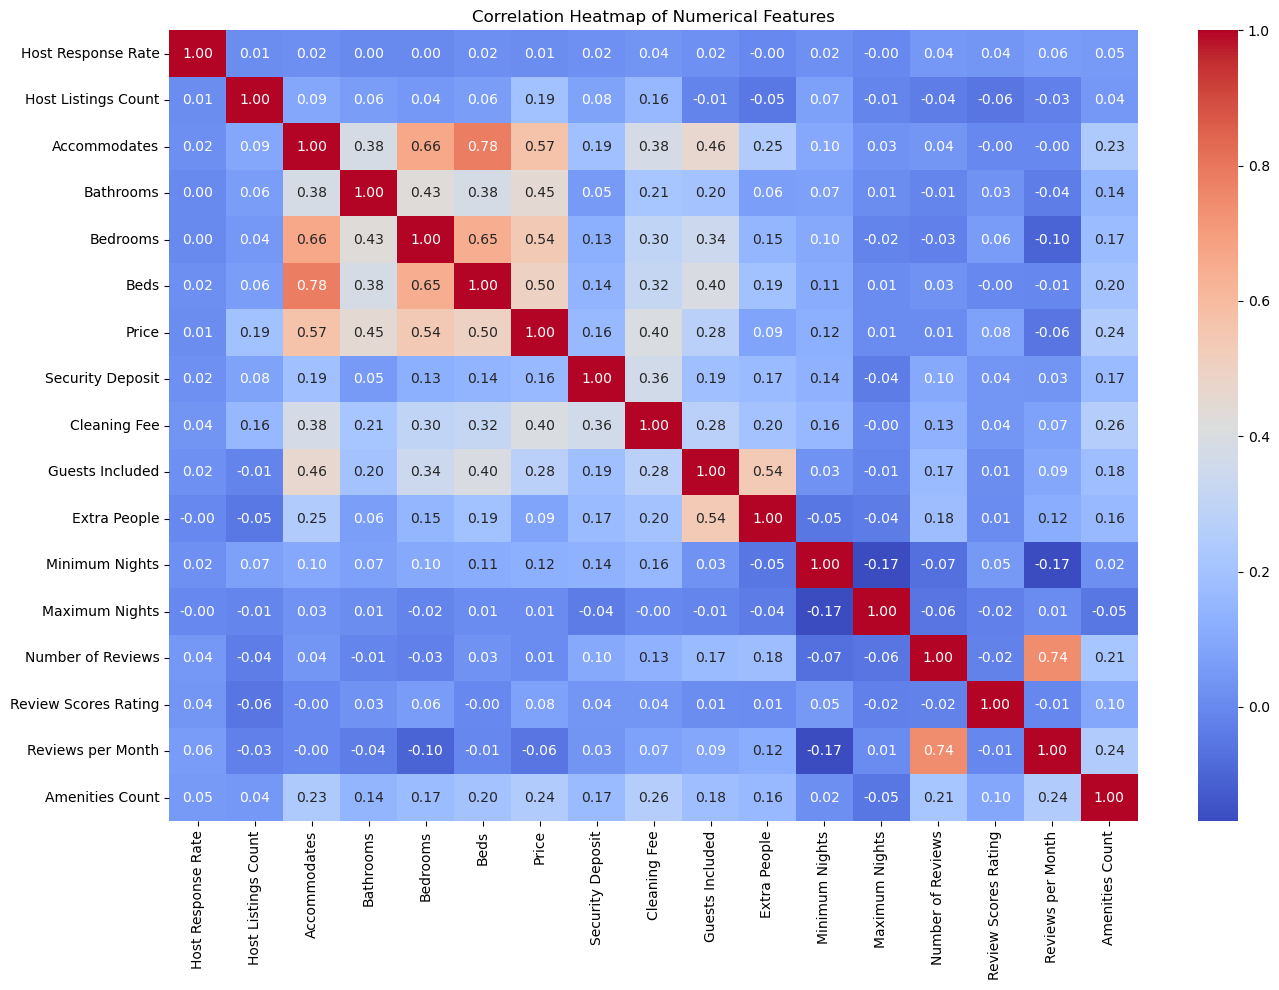

In [36]:
# Correlation Heatmap of Numerical Features
corr = df_ml[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [37]:
# Drop columns with high correlation with each other

df_ml = df_ml.drop(columns=['Beds', 'Number of Reviews'])

## 1. Price Prediction Model

**Model Used:** Simple Linear Regression

**Business Objective:** 
To analyze how listing characteristics influence pricing and evaluate the ability to predict price.

**Business Question:**
Can listing features effectively predict Airbnb prices?

In [38]:
# One feature and target
X = df_ml[['Accommodates']]
y = df_ml['Price']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model fitting
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# Model prediction
y_pred = lr_simple.predict(X_test)

# Print model evaluation
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

MAE: 36.43
RMSE: 60.83
MSE: 3700.72
R2: 0.333


**Model Interpretation:**
- The simple linear regression model shows moderate performance, explaining about 33% of price variation using only accommodates. This indicates that while capacity (number of guests) influences price, it is not the sole driver.
- The error values (MAE ≈ 36.43, RMSE ≈ 60.83) indicate noticeable prediction deviations, suggesting limited accuracy. The relatively high error suggests that listings with similar capacity can still have very different prices.
- In France, pricing is not purely based on size, and factors like property type, amenities, and uniqueness play a significant role.

## 2. Price Prediction (Multiple Features)

**Model Used:** Multiple Linear Regression

**Business Objective:**
To analyze how multiple property attributes and amenities collectively influence listing prices.

**Business Question:**
Can a combination of property features and amenities improve the accuracy of price prediction?

In [39]:
df_ml.corr()['Price'].sort_values(ascending=False)

Price                   1.000000
Accommodates            0.568253
Bedrooms                0.539852
Bathrooms               0.451177
Cleaning Fee            0.398791
Guests Included         0.275440
Amenities Count         0.242363
Cancellation Policy     0.197804
Host Listings Count     0.192791
Security Deposit        0.163863
Bed Type                0.137358
Minimum Nights          0.120902
Property Type           0.088834
Extra People            0.085298
Review Scores Rating    0.076178
has_deposit             0.019069
City                    0.016068
Host Response Rate      0.011770
Maximum Nights          0.008903
State                   0.004782
Reviews per Month      -0.055866
Amenities              -0.065955
Zipcode                -0.210076
Room Type              -0.210181
Name: Price, dtype: float64

In [40]:
mlr_features = [
    'Accommodates', 'Bedrooms', 'Bathrooms', 'Cleaning Fee', 
    'Security Deposit', 'Extra People', 'Guests Included', 'Amenities Count']

X = df_ml[mlr_features]
y = df_ml['Price']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Model fitting
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Model prediction
y_pred = lr_multi.predict(X_test)

# Print model evaluation
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

MAE: 32.59
RMSE: 54.36
MSE: 2955.26
R2: 0.467


**Model Interpretation:**

- The model shows moderate predictive performance, explaining about 46.7% of the variation in listing prices.
- Compared to the simple linear model, the lower error values (MAE and RMSE) indicate a clear improvement in prediction accuracy when multiple features are considered.
- This demonstrates that pricing in France is influenced by a combination of factors such as capacity, amenities, and listing characteristics rather than a single variable. However, since over half of the variation remains unexplained, it suggests that additional factors like location, property uniqueness, and host strategy also play a significant role.
- Pricing in France is multi-factor driven, and incorporating more listing attributes improves accuracy, but price variability remains relatively high due to market complexity.

## 3. Security Deposit Classification

**Model Used:** Logistic Regression

**Business Objective:**
To determine whether an Airbnb listing requires a security deposit based on pricing, property characteristics, host attributes, and booking-related features.

**Business Question:**
Can pricing, property, host, and booking characteristics predict whether an Airbnb listing requires a security deposit?

Logistic Regression Evaluation
Accuracy: 0.69

Confusion Matrix:
 [[3160 1899]
 [1597 4503]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.62      0.64      5059
         1.0       0.70      0.74      0.72      6100

    accuracy                           0.69     11159
   macro avg       0.68      0.68      0.68     11159
weighted avg       0.69      0.69      0.69     11159

ROC-AUC Score: 0.74


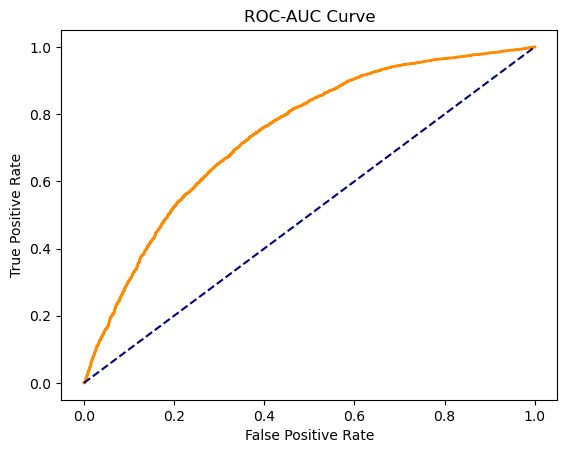

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve, auc

# Create Target Variable
df_ml['has_deposit'] = df['Security Deposit'] > 0

# Seperate features and target
X = df_ml[[
    'Price',
    'Cleaning Fee',
    'Extra People',
    'Accommodates',
    'Bedrooms',
    'Host Listings Count',
    'Reviews per Month',
    'Cancellation Policy'
]]
y = df_ml['has_deposit']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model fitting
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Model prediction
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# Print model evaluation
print("Logistic Regression Evaluation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_log), 2))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.show()

**Model Interpretation:**

- The logistic regression model was developed to predict whether an Airbnb listing requires a security deposit using pricing variables, property characteristics, and host-related features.
- The model achieved an accuracy of 69% and a ROC-AUC score of 0.74, indicating a moderate ability to distinguish between listings with and without security deposits.
- The confusion matrix shows relatively balanced classification performance, with the model performing slightly better in identifying listings that require security deposits (recall = 0.74) compared to listings without security deposits (recall = 0.62).
- Precision and recall values ranging between 0.66 and 0.70 suggest that the model performs consistently across both classes without substantial classification bias.
- Overall, the results indicate that security deposit requirements are influenced by measurable listing, pricing, and host characteristics, although some variation in host deposit decisions may be explained by additional factors not included in the model

## 4. Demand Segmentation

**Model Used:** KNN (K-Nearest Neighbors)

**Business Objective:** Classify listings based on demand intensity.

**Business Question:** Can we classify listings into high-demand and low-demand segments?

In [42]:
df_ml['high_demand'] = (df_ml['Reviews per Month'] > df_ml['Reviews per Month'].median())

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

X = df_ml[[
    'Price',
    'Cleaning Fee',
    'Accommodates',
    'Bedrooms',
    'Bathrooms',
    'Guests Included',
    'Amenities Count',
    'Review Scores Rating'
]]
y = df_ml['high_demand']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1,7)
accuracy_scores = []
roc_auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_prob))

    print(f"K={k:2d} | Accuracy={accuracy_scores[-1]:.3f} | ROC-AUC={roc_auc_scores[-1]:.3f}")

K= 1 | Accuracy=0.662 | ROC-AUC=0.662
K= 2 | Accuracy=0.651 | ROC-AUC=0.712
K= 3 | Accuracy=0.688 | ROC-AUC=0.733
K= 4 | Accuracy=0.683 | ROC-AUC=0.749
K= 5 | Accuracy=0.700 | ROC-AUC=0.756
K= 6 | Accuracy=0.691 | ROC-AUC=0.762


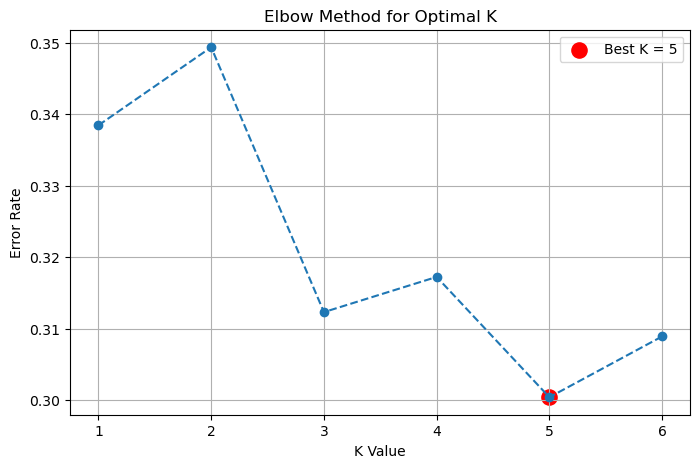

In [43]:
error_rate = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    error_rate.append(np.mean(y_pred != y_test))

# Plot Error Rate vs K
plt.figure(figsize=(8,5))

plt.plot(k_values, error_rate, marker='o', linestyle='--')

best_k = k_values[error_rate.index(min(error_rate))]
best_error = min(error_rate)

plt.scatter(best_k, best_error, color='red', s=120,
            label=f'Best K = {best_k}')

plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

KNN Classification Evaluation
Accuracy: 0.69

Confusion Matrix:
 [[4021 1564]
 [1876 3698]]

Classification Report:
               precision    recall  f1-score   support

       False       0.68      0.72      0.70      5585
        True       0.70      0.66      0.68      5574

    accuracy                           0.69     11159
   macro avg       0.69      0.69      0.69     11159
weighted avg       0.69      0.69      0.69     11159

ROC-AUC Score: 0.75


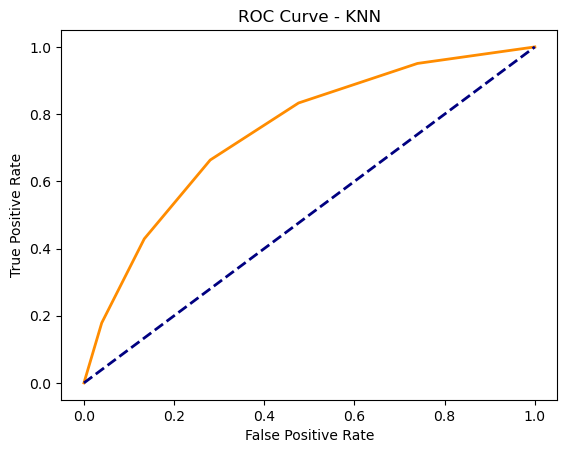

In [44]:
# Model fitting
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Model prediction
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# Print model evaluation
print("KNN Classification Evaluation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn), 2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_knn), 2))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.show()

**Performance Summary:**
- **Accuracy:** 0.69
- **ROC-AUC:** 0.75

**Model Interpretation:**
- The model shows good classification performance, with ~69% accuracy and a ROC-AUC of 0.75, indicating a strong ability to distinguish between high- and low-demand listings.
- The ROC curve being well above the diagonal confirms that the model performs significantly better than random guessing.
- Precision and recall are well balanced (~0.66–0.70), meaning the model is equally reliable in identifying both high-demand and low-demand listings.
- The confusion matrix shows some misclassification, but overall predictions are reasonably consistent and stable.
- Listing features (price, amenities, host attributes) have a meaningful impact on demand in France, and demand can be fairly well predicted using these variables.

## 5. Demand Segmentation

**Model Used:** K-Means Clustering

**Business Objective:**
To segment listings based on price and accommodation capacity to identify distinct market groups.

**Business Question:**
Can listings be grouped into meaningful segments using price and accommodates to understand different market tiers?

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_ml[['Price', 'Accommodates']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 11)

inertia_scores = []
silhouette_scores = []

print("K | Inertia | Silhouette Score")
print("-" * 40)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_scaled, labels)

    inertia_scores.append(inertia)
    silhouette_scores.append(sil_score)

    print(f"{k} | {inertia:.2f} | {sil_score:.4f}")

K | Inertia | Silhouette Score
----------------------------------------
2 | 60039.35 | 0.5777
3 | 36780.90 | 0.5617
4 | 28534.76 | 0.5415
5 | 24768.63 | 0.4639
6 | 23420.96 | 0.4740
7 | 20391.54 | 0.4731
8 | 16433.00 | 0.4889
9 | 14857.75 | 0.4898
10 | 13421.37 | 0.4749


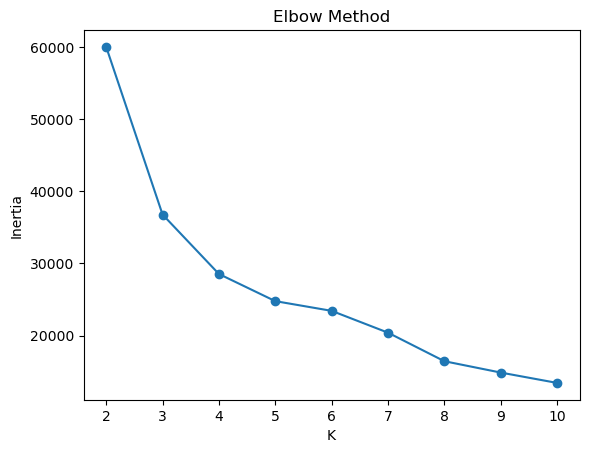

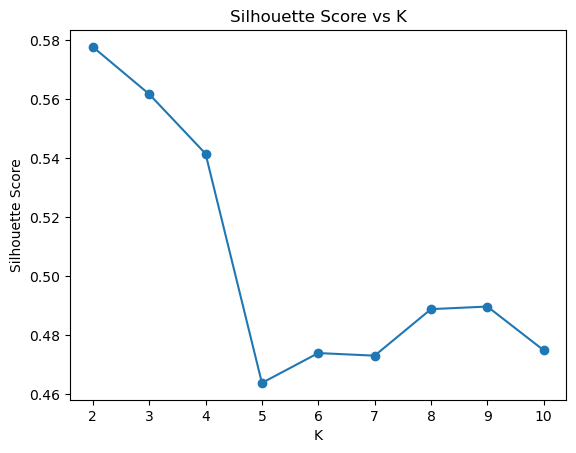

In [46]:
# Elbow Plot
plt.figure()
plt.plot(k_values, inertia_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Plot
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

Listing_Cluster
0    33771
1     3066
2    18958
Name: count, dtype: int64

Cluster Centroids:
        Price  Accommodates
0   66.374878      2.065855
1  316.670554      6.008098
2  108.374241      4.275545


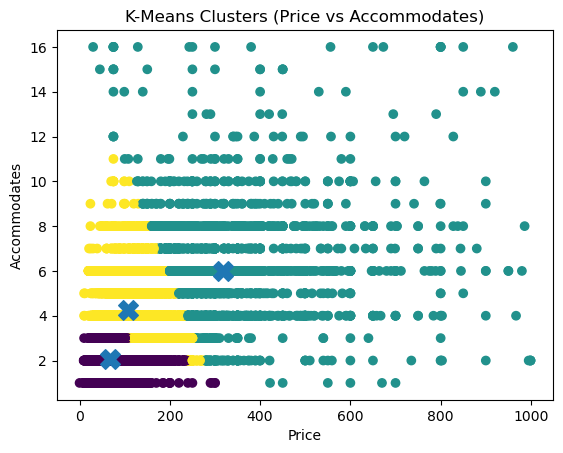

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_ml['Listing_Cluster'] = kmeans.fit_predict(X_scaled)

cluster_counts = df_ml['Listing_Cluster'].value_counts().sort_index()

print(cluster_counts)

centroids_scaled = kmeans.cluster_centers_

# Convert back to original scale
centroids = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids, columns=['Price', 'Accommodates'])

print("\nCluster Centroids:")
print(centroid_df)

plt.figure()

plt.scatter(
    df_ml['Price'],
    df_ml['Accommodates'],
    c=df_ml['Listing_Cluster']
)

# Plot centroids
plt.scatter(
    centroid_df['Price'],
    centroid_df['Accommodates'],
    marker='X',
    s=200
)

plt.xlabel("Price")
plt.ylabel("Accommodates")
plt.title("K-Means Clusters (Price vs Accommodates)")
plt.show()

In [48]:
# K-means clustering evaluation metrics

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Cluster labels
cluster_labels = kmeans.labels_

# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", round(silhouette_avg, 3))

# Calinski-Harabasz Score
calinski_harabasz = calinski_harabasz_score(X_scaled, cluster_labels)
print("Calinski-Harabasz Score:", round(calinski_harabasz, 3))

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
print("Davies-Bouldin Index:", round(davies_bouldin, 3))

Silhouette Score: 0.562
Calinski-Harabasz Score: 56739.024
Davies-Bouldin Index: 0.759


**Model Interpretation:**

- The K-Means clustering model identifies 3 optimal clusters (K = 3) based on the elbow method and a relatively high silhouette score (~0.56), indicating well-defined clusters.
- The results highlight that the market is naturally divided into budget, mid-range, and premium segments, where pricing consistently increases with accommodation capacity.
- Evaluation metrics (high Calinski-Harabasz and low Davies-Bouldin index) confirm good cluster separation and compactness, making the segmentation meaningful for analyzing demand patterns.
- Since the model uses price and accommodates as inputs, the clustering clearly reflects a structured relationship between listing size and pricing.

**Cluster 0 (Budget Segment)**
- Low price (66) and low accommodates (2)
- Compact, affordable listings targeting budget travelers
- Largest segment in the market

**Cluster 2 (Mid-Range Segment)**
- Moderate price (108) and accommodates (4)
- Balanced listings suitable for small groups
- Core market segment

**Cluster 1 (Premium Segment)**
- High price (316) and higher accommodates (6)
- Spacious, premium listings targeting larger groups
- Smaller but high-value segment